# Chronos-2 zero-shot forecasting case study: building electricity demand

This notebook supports the article section: **What new things can you actually do with Chronos-2?**

We use one synthetic building-demand dataset to walk through four zero-shot usage patterns:

1. univariate forecasting
2. multivariate forecasting
3. forecasting with known-future covariates
4. cross-learning for a short-history building

The central idea is simple: the pretrained model stays the same; the forecasting mode changes based on how we organize the dataframe at inference time.

## 1. Setup

Chronos-2 runs on CPU or GPU. This notebook uses CUDA when PyTorch can see it, otherwise it falls back to CPU.

In [1]:
from pathlib import Path
import warnings

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

from chronos import Chronos2Pipeline

warnings.filterwarnings("ignore", message="The given NumPy array is not writable*")

SEED = 42
PREDICTION_LENGTH = 168  # one week of hourly forecasts
CONTEXT_DAYS = 45
BATCH_SIZE = 64
MODEL_ID = "amazon/chronos-2"

LOWER_QUANTILE = 0.025
MEDIAN_QUANTILE = 0.5
UPPER_QUANTILE = 0.975
QUANTILE_LEVELS = [LOWER_QUANTILE, MEDIAN_QUANTILE, UPPER_QUANTILE]
LOWER_QUANTILE_COLUMN = f"{LOWER_QUANTILE:g}"
UPPER_QUANTILE_COLUMN = f"{UPPER_QUANTILE:g}"
INTERVAL_PERCENT = int(round((UPPER_QUANTILE - LOWER_QUANTILE) * 100))
COVERAGE_COLUMN = f"{INTERVAL_PERCENT}% coverage"

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

device_map = "cuda" if torch.cuda.is_available() else "cpu"
device_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

print(f"PyTorch: {torch.__version__}")
print(f"Device: {device_name}")

PyTorch: 2.11.0+cu128
Device: NVIDIA RTX 2000 Ada Generation Laptop GPU


In [2]:
pipeline = Chronos2Pipeline.from_pretrained(MODEL_ID, device_map=device_map)
print(f"Loaded {MODEL_ID} with device_map={device_map!r}")

Loaded amazon/chronos-2 with device_map='cuda'


## 2. Generate the synthetic dataset

We simulate eight office buildings. Total demand is the sum of base load, plug load, lighting load, and HVAC load. HVAC comes from a simple thermal model, while plug and lighting loads follow weekday occupancy patterns.

The forecast week is generated by the same process as the history. The goal is not to create a benchmark; it is to create a clean, realistic-enough playground for the Chronos-2 input patterns.

In [3]:
START_DATE = pd.Timestamp("2025-03-01 00:00")
N_DAYS = 170
TIMESTAMPS = pd.date_range(START_DATE, periods=N_DAYS * 24, freq="h")
cutoff_date = pd.Timestamp("2025-07-14 00:00")
forecast_end_date = cutoff_date + pd.Timedelta(hours=PREDICTION_LENGTH - 1)
context_start_date = cutoff_date - pd.Timedelta(days=CONTEXT_DAYS)


def sigmoid(x: np.ndarray | float) -> np.ndarray | float:
    return 1.0 / (1.0 + np.exp(-x))


def outdoor_temperature(index: pd.DatetimeIndex) -> np.ndarray:
    hour = index.hour.to_numpy()
    day = ((index - START_DATE).days).to_numpy()
    daily_cycle = 7.0 * np.sin(2 * np.pi * (hour - 15) / 24)
    seasonal_trend = 18.5 + 0.045 * day
    synoptic_variation = 2.2 * np.sin(2 * np.pi * day / 9 + 0.8) + 1.2 * np.sin(2 * np.pi * day / 17)
    return seasonal_trend + daily_cycle + synoptic_variation


def solar_profile(index: pd.DatetimeIndex) -> np.ndarray:
    hour = index.hour.to_numpy()
    day = ((index - START_DATE).days).to_numpy()
    daylight = np.clip(np.sin(np.pi * (hour - 6) / 13), 0, None)
    seasonal_strength = 0.8 + 0.2 * np.sin(2 * np.pi * (day - 40) / 365)
    return daylight * seasonal_strength


def occupancy_profile(index: pd.DatetimeIndex, scale: float) -> np.ndarray:
    hour = index.hour.to_numpy()
    day_of_week = index.dayofweek.to_numpy()
    weekday = (day_of_week < 5).astype(float)
    workday_shape = sigmoid((hour - 7.5) / 1.0) * sigmoid((18.0 - hour) / 1.2)
    lunch_dip = 1.0 - 0.12 * np.exp(-((hour - 12.5) / 1.3) ** 2)
    return scale * weekday * workday_shape * lunch_dip


def simulate_building(
    building: str,
    floor_area_m2: float,
    occupancy_scale: float,
    insulation_factor: float,
    hvac_size_factor: float,
    cooling_setpoint_c: float,
    heating_setpoint_c: float,
    plug_scale: float,
) -> pd.DataFrame:
    n = len(TIMESTAMPS)
    building_seed = SEED + int(building.split()[-1]) * 97
    local_rng = np.random.default_rng(building_seed)

    outdoor_temp = outdoor_temperature(TIMESTAMPS)
    solar = solar_profile(TIMESTAMPS)
    occupancy = occupancy_profile(TIMESTAMPS, occupancy_scale)
    thermal_mass = floor_area_m2 * 0.058  # kWh per C
    thermal_resistance = 0.022 * insulation_factor  # C per kW
    max_cooling_kw = floor_area_m2 * 0.034 * hvac_size_factor
    max_heating_kw = floor_area_m2 * 0.020 * hvac_size_factor
    controller_gain = floor_area_m2 * 0.014 * hvac_size_factor
    cooling_cop = 3.1
    heating_cop = 3.4

    indoor_temp = np.zeros(n)
    base_load = np.zeros(n)
    plug_load = np.zeros(n)
    lighting_load = np.zeros(n)
    hvac_load = np.zeros(n)
    total_load = np.zeros(n)
    cooling_thermal = np.zeros(n)
    heating_thermal = np.zeros(n)

    indoor_temp[0] = 23.0

    for t in range(n - 1):
        active_cooling_setpoint = cooling_setpoint_c

        plug_load[t] = (
            floor_area_m2 * (0.0045 + 0.0100 * plug_scale * occupancy[t])
            + local_rng.normal(0, floor_area_m2 * 0.00018)
        )
        lighting_load[t] = (
            floor_area_m2 * (0.0020 + 0.0060 * occupancy[t] * (1.0 - 0.45 * solar[t]))
            + local_rng.normal(0, floor_area_m2 * 0.00018)
        )
        base_load[t] = floor_area_m2 * 0.0035 + 5.0 * np.sin(2 * np.pi * t / (24 * 14))

        internal_gain_kw = 0.65 * plug_load[t] + 0.85 * lighting_load[t] + floor_area_m2 * 0.0012 * occupancy[t]
        solar_gain_kw = floor_area_m2 * 0.012 * solar[t]

        cooling_need = max(0.0, indoor_temp[t] - active_cooling_setpoint)
        heating_need = max(0.0, heating_setpoint_c - indoor_temp[t])
        desired_cooling = min(max_cooling_kw, controller_gain * cooling_need)
        desired_heating = min(max_heating_kw, controller_gain * heating_need)
        previous_cooling = cooling_thermal[t - 1] if t > 0 else 0.0
        previous_heating = heating_thermal[t - 1] if t > 0 else 0.0
        cooling_thermal[t] = 0.55 * previous_cooling + 0.45 * desired_cooling
        heating_thermal[t] = 0.55 * previous_heating + 0.45 * desired_heating
        hvac_load[t] = cooling_thermal[t] / cooling_cop + heating_thermal[t] / heating_cop

        temperature_change = (
            (outdoor_temp[t] - indoor_temp[t]) / thermal_resistance
            + internal_gain_kw
            + solar_gain_kw
            - cooling_thermal[t]
            + heating_thermal[t]
        ) / thermal_mass
        indoor_temp[t + 1] = indoor_temp[t] + temperature_change

        total_load[t] = max(
            0.0,
            base_load[t] + plug_load[t] + lighting_load[t] + hvac_load[t] + local_rng.normal(0, floor_area_m2 * 0.00035),
        )

    base_load[-1] = base_load[-2]
    plug_load[-1] = plug_load[-2]
    lighting_load[-1] = lighting_load[-2]
    hvac_load[-1] = hvac_load[-2]
    total_load[-1] = base_load[-1] + plug_load[-1] + lighting_load[-1] + hvac_load[-1]

    return pd.DataFrame(
        {
            "building": building,
            "timestamp": TIMESTAMPS,
            "total_load_kw": total_load,
            "hvac_load_kw": hvac_load,
            "plug_load_kw": plug_load,
            "lighting_load_kw": lighting_load,
            "indoor_temp_c": indoor_temp,
            "outdoor_temp_c": outdoor_temp,
            "occupancy": occupancy,
            "solar_irradiance": solar,
            "is_weekend": (TIMESTAMPS.dayofweek >= 5).astype(int),
        }
    )


def make_dataset() -> pd.DataFrame:
    building_profiles = [
        # building, floor_area_m2, occupancy_scale, insulation_factor, hvac_size_factor, cooling_setpoint_c, heating_setpoint_c, plug_scale
        ("Building 01", 9_200, 1.00, 0.92, 1.05, 24.0, 19.0, 0.95),
        ("Building 02", 7_600, 0.88, 1.10, 0.92, 24.5, 19.0, 0.85),
        ("Building 03", 10_400, 1.18, 0.85, 1.15, 24.0, 19.5, 1.05),
        ("Building 04", 6_800, 0.75, 1.30, 0.75, 24.0, 19.0, 0.70),
        ("Building 05", 11_800, 1.30, 0.78, 1.25, 23.5, 19.0, 1.15),
        ("Building 06", 8_400, 0.95, 1.05, 0.90, 24.5, 19.5, 0.82),
        ("Building 07", 9_800, 1.08, 0.95, 1.00, 24.0, 19.0, 1.00),
        ("Building 08", 10_000, 1.12, 0.90, 1.12, 24.0, 19.5, 1.02),
    ]
    return pd.concat([simulate_building(*profile) for profile in building_profiles], ignore_index=True)


full_df = make_dataset()
history_df = full_df[
    (full_df["timestamp"] >= context_start_date)
    & (full_df["timestamp"] < cutoff_date)
].copy()
future_truth_df = full_df[
    (full_df["timestamp"] >= cutoff_date)
    & (full_df["timestamp"] < cutoff_date + pd.Timedelta(hours=PREDICTION_LENGTH))
].copy()
future_covariates_df = future_truth_df[
    ["building", "timestamp", "outdoor_temp_c", "occupancy", "solar_irradiance", "is_weekend"]
].copy()

story_building = "Building 03"
new_building = "Building 06"
established_buildings = [building for building in sorted(full_df["building"].unique()) if building != new_building]

case_brief = pd.DataFrame(
    [
        {"Setting": "Forecast start", "Value": cutoff_date},
        {"Setting": "Horizon", "Value": f"{PREDICTION_LENGTH} hourly steps"},
        {"Setting": "Context per established building", "Value": f"{CONTEXT_DAYS} days"},
        {"Setting": "Main walkthrough building", "Value": story_building},
        {"Setting": "Short-history building", "Value": new_building},
    ]
)
case_brief

,Setting,Value
0,Forecast start,2025-07-14 00:00:00
1,Horizon,168 hourly steps
2,Context per established building,45 days
3,Main walkthrough building,Building 03
4,Short-history building,Building 06


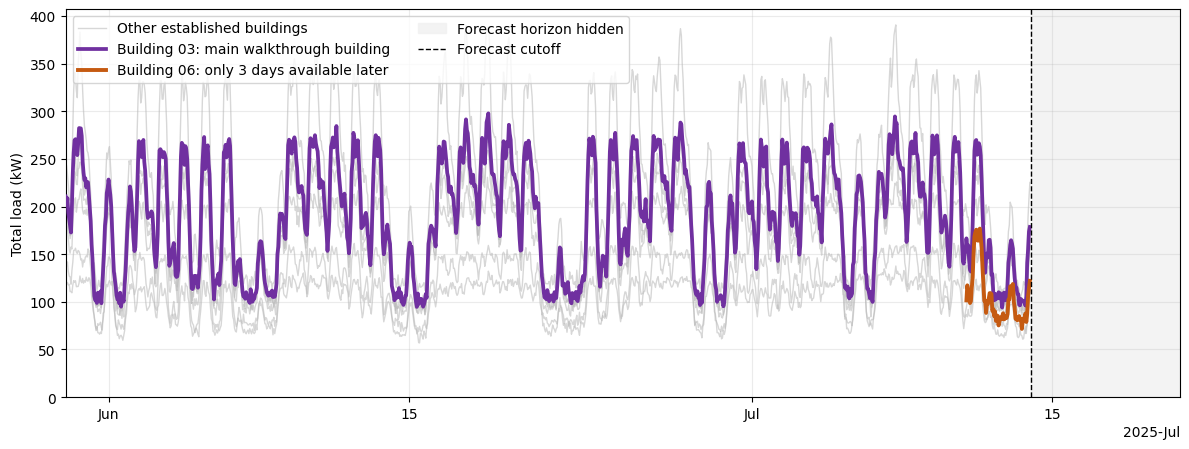

In [4]:
fig, ax = plt.subplots(figsize=(12, 4.6))
plot_start = context_start_date
plot_end = forecast_end_date
short_setup_start = cutoff_date - pd.Timedelta(days=3)

setup_window = full_df[(full_df["timestamp"] >= plot_start) & (full_df["timestamp"] < cutoff_date)]

for building, building_df in setup_window.groupby("building"):
    if building == new_building:
        building_df = building_df[building_df["timestamp"] >= short_setup_start]

    if building == story_building:
        color, linewidth, alpha, label, zorder = "#7030a0", 2.7, 1.0, f"{building}: main walkthrough building", 4
    elif building == new_building:
        color, linewidth, alpha, label, zorder = "#c55a11", 2.8, 1.0, f"{building}: only 3 days available later", 5
    else:
        color, linewidth, alpha, label, zorder = "#b7b7b7", 1.0, 0.55, "Other established buildings", 2
        if label in ax.get_legend_handles_labels()[1]:
            label = None

    ax.plot(
        building_df["timestamp"],
        building_df["total_load_kw"],
        color=color,
        linewidth=linewidth,
        alpha=alpha,
        label=label,
        zorder=zorder,
    )

ax.axvspan(cutoff_date, forecast_end_date, color="#f2f2f2", alpha=0.9, label="Forecast horizon hidden")
ax.axvline(cutoff_date, color="black", linestyle="--", linewidth=1, label="Forecast cutoff", zorder=6)
ax.set_xlim(plot_start, plot_end)
ax.set_ylabel("Total load (kW)")
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend(loc="upper left", ncols=2)
locator = mdates.AutoDateLocator(minticks=4, maxticks=7)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
plt.tight_layout()
fig.savefig(FIGURES_DIR / "00_case_study_setup.png", dpi=160, bbox_inches="tight")

## 3. Plotting and metrics

These small helpers keep the four Chronos-2 calls focused on the dataframe shape.

In [5]:
def chronos_predict(context: pd.DataFrame, target: str | list[str], **kwargs) -> pd.DataFrame:
    return pipeline.predict_df(
        context,
        prediction_length=PREDICTION_LENGTH,
        quantile_levels=QUANTILE_LEVELS,
        id_column="building",
        timestamp_column="timestamp",
        target=target,
        batch_size=BATCH_SIZE,
        **kwargs,
    )


def savefig(filename: str) -> None:
    plt.gcf().savefig(FIGURES_DIR / filename, dpi=160, bbox_inches="tight")


def format_date_axis(ax: plt.Axes) -> None:
    locator = mdates.AutoDateLocator(minticks=4, maxticks=7)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))


def prediction_slice(predictions: pd.DataFrame, building: str, target: str) -> pd.DataFrame:
    return predictions[
        predictions["building"].eq(building) & predictions["target_name"].eq(target)
    ].sort_values("timestamp")


def nonnegative(values: pd.Series) -> pd.Series:
    return values.clip(lower=0)


def plot_forecast(
    history: pd.DataFrame,
    future: pd.DataFrame,
    predictions: pd.DataFrame,
    building: str,
    target: str = "total_load_kw",
    title: str | None = None,
    ax: plt.Axes | None = None,
) -> plt.Axes:
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 4))

    history_part = history[history["building"].eq(building)]
    future_part = future[future["building"].eq(building)]
    pred_part = prediction_slice(predictions, building, target)

    ax.plot(history_part["timestamp"], history_part[target], color="#2f5597", label="History")
    ax.plot(future_part["timestamp"], future_part[target], color="#548235", label="Ground truth")
    ax.plot(pred_part["timestamp"], nonnegative(pred_part["predictions"]), color="#7030a0", label="Chronos-2 median")
    ax.fill_between(
        pred_part["timestamp"],
        nonnegative(pred_part[LOWER_QUANTILE_COLUMN]),
        nonnegative(pred_part[UPPER_QUANTILE_COLUMN]),
        color="#c5b4e3",
        alpha=0.45,
        label=f"{INTERVAL_PERCENT}% interval",
    )
    ax.axvline(cutoff_date, color="black", linestyle="--", linewidth=1)
    if title:
        ax.set_title(title)
    ax.set_ylabel(target.replace("_", " "))
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left")
    format_date_axis(ax)
    return ax


def plot_target_grid(history: pd.DataFrame, future: pd.DataFrame, predictions: pd.DataFrame, building: str, targets: list[str]) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 7), sharex=True)
    for ax, target in zip(axes.ravel(), targets):
        plot_forecast(history, future, predictions, building, target=target, title=target.replace("_", " "), ax=ax)
        if target != targets[0]:
            ax.legend().remove()
    plt.tight_layout()


def plot_forecast_comparison(
    history: pd.DataFrame,
    future: pd.DataFrame,
    first: pd.DataFrame,
    second: pd.DataFrame,
    building: str,
    first_label: str,
    second_label: str,
    target: str = "total_load_kw",
) -> None:
    history_part = history[history["building"].eq(building)]
    future_part = future[future["building"].eq(building)]
    first_part = prediction_slice(first, building, target)
    second_part = prediction_slice(second, building, target)

    _, ax = plt.subplots(figsize=(11, 4))
    ax.plot(history_part["timestamp"], history_part[target], color="#2f5597", label="History")
    ax.plot(future_part["timestamp"], future_part[target], color="#548235", label="Ground truth")
    ax.plot(first_part["timestamp"], nonnegative(first_part["predictions"]), color="#a64d79", label=first_label)
    ax.plot(second_part["timestamp"], nonnegative(second_part["predictions"]), color="#7030a0", label=second_label)
    ax.fill_between(
        second_part["timestamp"],
        nonnegative(second_part[LOWER_QUANTILE_COLUMN]),
        nonnegative(second_part[UPPER_QUANTILE_COLUMN]),
        color="#c5b4e3",
        alpha=0.35,
    )
    ax.axvline(cutoff_date, color="black", linestyle="--", linewidth=1)
    ax.set_ylabel(target.replace("_", " "))
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left")
    format_date_axis(ax)
    plt.tight_layout()


def plot_known_covariates(history: pd.DataFrame, future: pd.DataFrame, building: str) -> None:
    history_part = history[history["building"].eq(building)]
    future_part = future[future["building"].eq(building)]
    covariates = [
        ("outdoor_temp_c", "Temp (C)", "#2f5597"),
        ("occupancy", "Occupancy", "#548235"),
        ("solar_irradiance", "Solar", "#bf9000"),
    ]

    fig, axes = plt.subplots(3, 1, figsize=(11, 6.4), sharex=True)
    for ax, (column, label, color) in zip(axes, covariates):
        ax.plot(history_part["timestamp"], history_part[column], color=color, linewidth=1.3, alpha=0.75, label="History")
        ax.plot(future_part["timestamp"], future_part[column], color=color, linewidth=2.2, label="Known future")
        ax.axvline(cutoff_date, color="black", linestyle="--", linewidth=1)
        ax.axvspan(cutoff_date, forecast_end_date, color="#f2f2f2", alpha=0.55)
        ax.set_ylabel(label)
        ax.grid(alpha=0.25)
        format_date_axis(ax)
    axes[0].set_title(f"Historical and known-future covariates for {building}")
    axes[0].legend(loc="upper left", ncols=2)
    axes[2].set_ylim(bottom=0)
    plt.tight_layout()


def metric_row(
    predictions: pd.DataFrame,
    truth: pd.DataFrame,
    target: str,
    label: str,
    buildings: list[str] | None = None,
    subset: str = "all",
    subset_filter=None,
) -> dict:
    pred = predictions.loc[
        predictions["target_name"].eq(target),
        ["building", "timestamp", "predictions", LOWER_QUANTILE_COLUMN, UPPER_QUANTILE_COLUMN],
    ]
    truth_columns = ["building", "timestamp", target, "occupancy"]
    truth_part = truth[[column for column in truth_columns if column in truth.columns]]
    merged = truth_part.merge(pred, on=["building", "timestamp"], how="inner")

    if buildings is not None:
        merged = merged[merged["building"].isin(buildings)]
    if subset_filter is not None:
        merged = merged[subset_filter(merged)]

    y = merged[target].to_numpy()
    yhat = merged["predictions"].to_numpy()
    lower = merged[LOWER_QUANTILE_COLUMN].to_numpy()
    upper = merged[UPPER_QUANTILE_COLUMN].to_numpy()
    error = np.abs(y - yhat)

    return {
        "label": label,
        "subset": subset,
        "target": target,
        "n": len(merged),
        "MAE": error.mean(),
        "RMSE": np.sqrt(np.mean((y - yhat) ** 2)),
        "WAPE": error.sum() / np.maximum(np.abs(y).sum(), 1e-9),
        "sMAPE": np.mean(2 * error / (np.abs(y) + np.abs(yhat) + 1e-9)),
        COVERAGE_COLUMN: np.mean((y >= lower) & (y <= upper)),
    }


def format_metrics(metrics: pd.DataFrame) -> pd.DataFrame:
    formatted = metrics.copy()
    for column in ["MAE", "RMSE"]:
        formatted[column] = formatted[column].round(1)
    for column in ["WAPE", "sMAPE", COVERAGE_COLUMN]:
        formatted[column] = (100 * formatted[column]).round(1).astype(str) + "%"
    return formatted


def wape_reduction(metrics: pd.DataFrame, baseline_label: str, challenger_label: str) -> float:
    baseline = metrics.loc[metrics["label"].eq(baseline_label), "WAPE"].iloc[0]
    challenger = metrics.loc[metrics["label"].eq(challenger_label), "WAPE"].iloc[0]
    return 1.0 - challenger / baseline

## 4. Can Chronos-2 forecast building demand zero-shot?

Start with the simplest setup: one target column, one forecast horizon, no covariates, and no model training.

,label,subset,target,n,MAE,RMSE,WAPE,sMAPE,95% coverage
0,Zero-shot univariate,all,total_load_kw,1344,14.9,19.4,8.4%,9.0%,93.2%


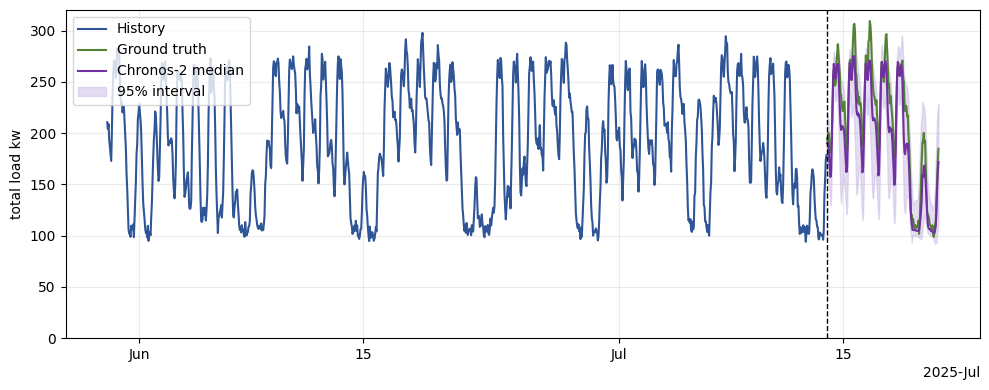

In [6]:
context_univariate = history_df[["building", "timestamp", "total_load_kw"]].copy()

pred_univariate = chronos_predict(context_univariate, target="total_load_kw")

plot_forecast(context_univariate, future_truth_df, pred_univariate, building=story_building)
plt.tight_layout()
savefig("01_univariate_forecast.png")

metrics_univariate = pd.DataFrame(
    [metric_row(pred_univariate, future_truth_df, target="total_load_kw", label="Zero-shot univariate")]
)
format_metrics(metrics_univariate)

## 5. Can it forecast load components jointly?

Here, total demand, HVAC demand, plug load, and lighting load are all targets in the same call.

,label,subset,target,n,MAE,RMSE,WAPE,sMAPE,95% coverage
0,Multivariate zero-shot,all,total_load_kw,1344,9.6,13.2,5.4%,5.9%,99.1%
1,Multivariate zero-shot,all,hvac_load_kw,1344,6.9,9.9,15.1%,46.5%,94.8%
2,Multivariate zero-shot,all,plug_load_kw,1344,1.6,2.0,2.2%,2.6%,95.7%
3,Multivariate zero-shot,all,lighting_load_kw,1344,1.4,1.8,4.5%,5.5%,96.6%


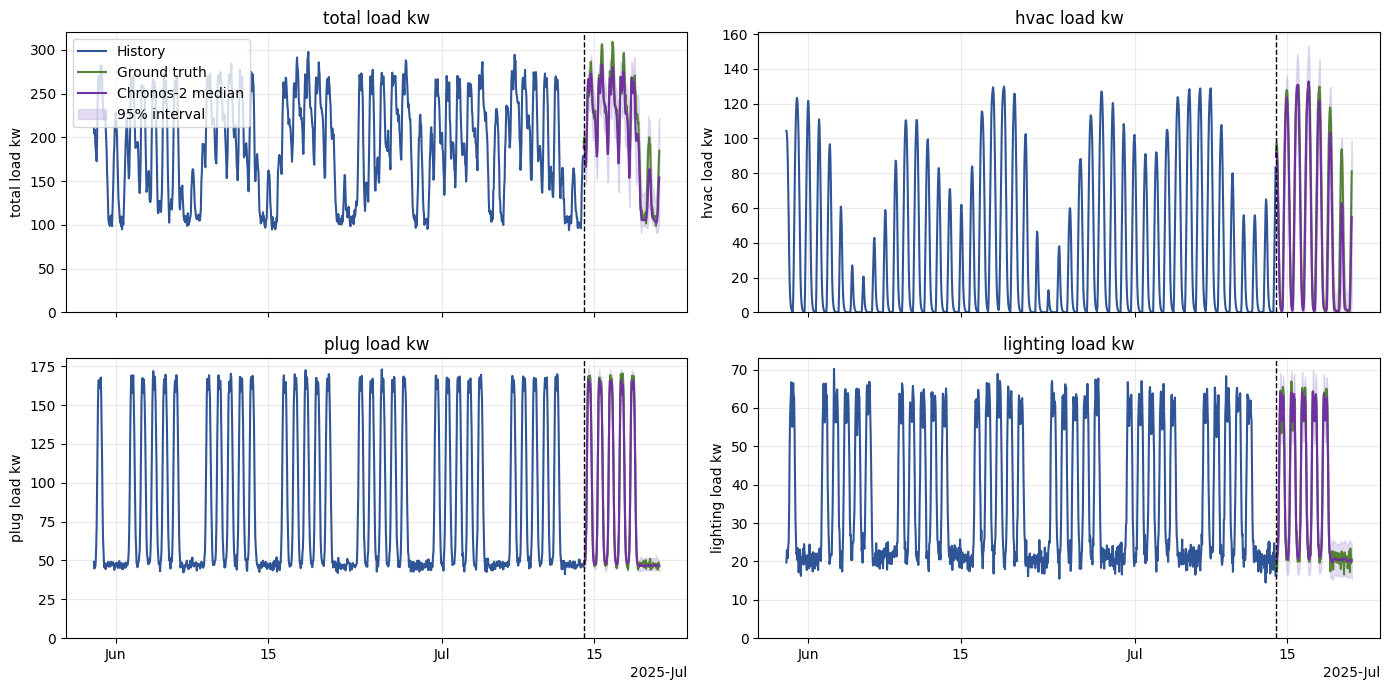

In [7]:
target_columns = ["total_load_kw", "hvac_load_kw", "plug_load_kw", "lighting_load_kw"]
context_multivariate = history_df[["building", "timestamp"] + target_columns].copy()

pred_multivariate = chronos_predict(context_multivariate, target=target_columns)

plot_target_grid(context_multivariate, future_truth_df, pred_multivariate, building=story_building, targets=target_columns)
savefig("02_multivariate_forecast.png")

metrics_multivariate = pd.DataFrame(
    [metric_row(pred_multivariate, future_truth_df, target=target, label="Multivariate zero-shot") for target in target_columns]
)
format_metrics(metrics_multivariate)

## 6. Can it use known future weather and operating schedules?

Known-future covariates must appear in both places: the historical context and `future_df`. Here we use outdoor temperature, occupancy, solar irradiance, and weekend flag.

,label,subset,target,n,MAE,RMSE,WAPE,sMAPE,95% coverage
0,No future covariates,all,total_load_kw,1344,14.9,19.4,8.4%,9.0%,93.2%
1,With known future covariates,all,total_load_kw,1344,7.4,9.7,4.2%,4.5%,98.1%


Adding known future covariates reduces WAPE from 8.4% to 4.2%, a 50.2% reduction.


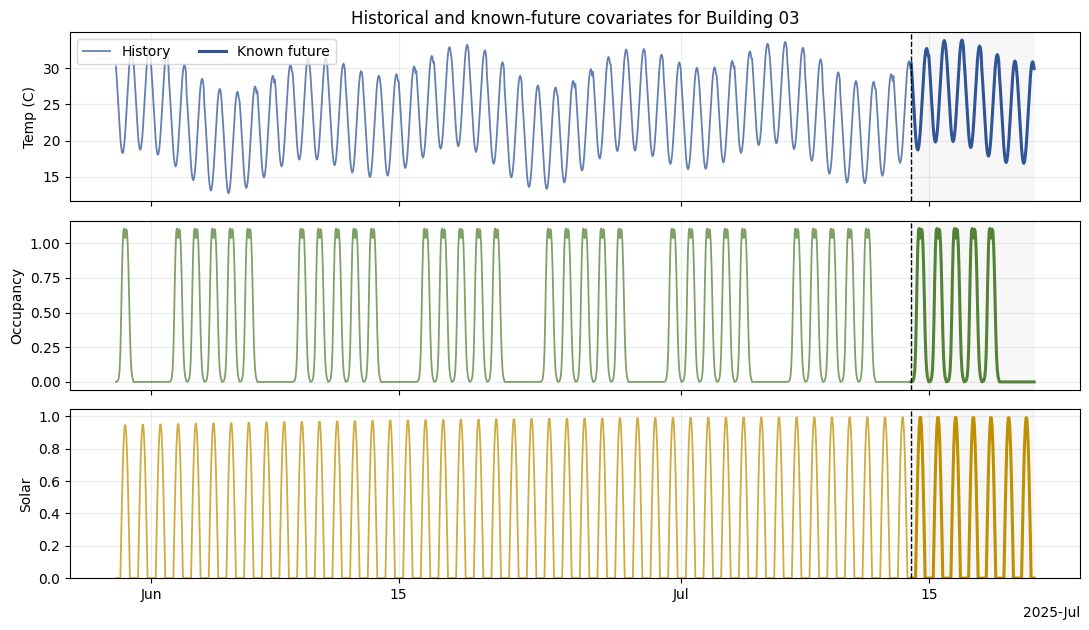

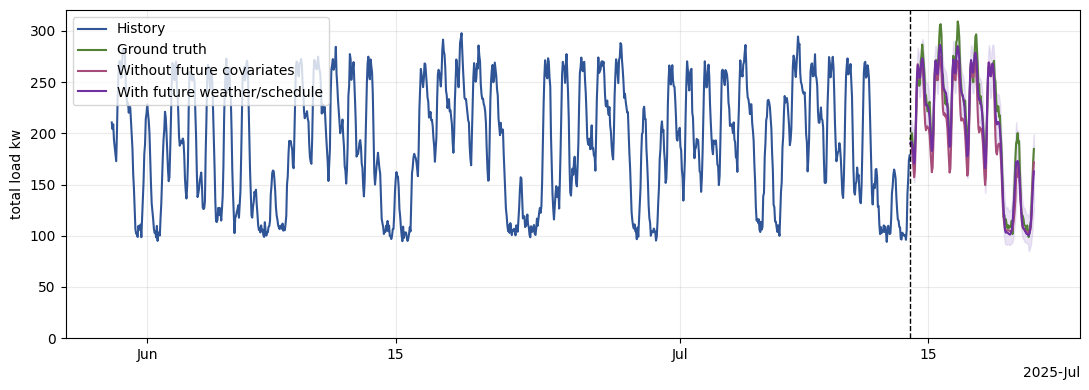

In [8]:
known_future_columns = ["outdoor_temp_c", "occupancy", "solar_irradiance", "is_weekend"]
context_with_covariates = history_df[["building", "timestamp", "total_load_kw"] + known_future_columns].copy()

plot_known_covariates(context_with_covariates, future_covariates_df, story_building)
savefig("03_known_future_covariates.png")

pred_with_covariates = chronos_predict(
    context_with_covariates,
    target="total_load_kw",
    future_df=future_covariates_df,
)

plot_forecast_comparison(
    context_with_covariates,
    future_truth_df,
    first=pred_univariate,
    second=pred_with_covariates,
    building=story_building,
    first_label="Without future covariates",
    second_label="With future weather/schedule",
)
savefig("03_known_future_covariate_forecast.png")

metrics_covariates = pd.DataFrame(
    [
        metric_row(pred_univariate, future_truth_df, target="total_load_kw", label="No future covariates"),
        metric_row(pred_with_covariates, future_truth_df, target="total_load_kw", label="With known future covariates"),
    ]
)

display(format_metrics(metrics_covariates))

covariate_reduction = wape_reduction(metrics_covariates, "No future covariates", "With known future covariates")
print(
    "Adding known future covariates reduces WAPE "
    f"from {100 * metrics_covariates.loc[0, 'WAPE']:.1f}% "
    f"to {100 * metrics_covariates.loc[1, 'WAPE']:.1f}%, "
    f"a {covariate_reduction:.1%} reduction."
)

## 7. Can related buildings help a newly metered building?

For `Building 06`, we keep only three days of history. We run Chronos-2 twice: first on that short history alone, then with the established buildings' 45-day histories in the same call.

No future covariates or sibling future loads are used in this section.

,label,subset,target,n,MAE,RMSE,WAPE,sMAPE,95% coverage
0,Isolated short-history,all,total_load_kw,168,32.5,39.0,22.2%,23.7%,100.0%
1,Cross-learning,all,total_load_kw,168,24.5,32.4,16.7%,17.9%,100.0%


Cross-learning reduces WAPE for Building 06 from 22.2% to 16.7%, a 24.7% reduction.


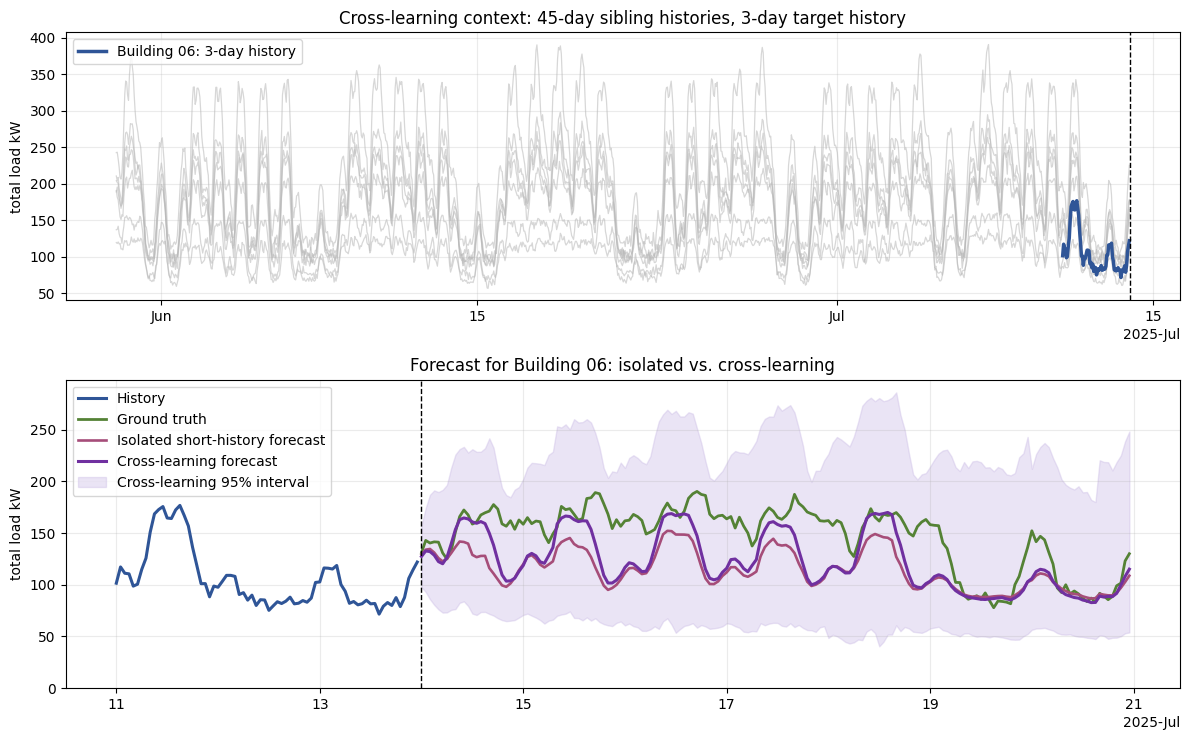

In [9]:
short_building = new_building
short_history_days = 3
short_history_start = cutoff_date - pd.Timedelta(days=short_history_days)

cold_context = pd.concat(
    [
        context_univariate[context_univariate["building"] != short_building],
        context_univariate[
            context_univariate["building"].eq(short_building)
            & (context_univariate["timestamp"] >= short_history_start)
        ],
    ],
    ignore_index=True,
).sort_values(["building", "timestamp"])

cold_context_new_only = cold_context[cold_context["building"].eq(short_building)].copy()

pred_cold_independent = chronos_predict(
    cold_context_new_only,
    target="total_load_kw",
    cross_learning=False,
)

pred_cold_cross = chronos_predict(
    cold_context,
    target="total_load_kw",
    cross_learning=True,
)

sibling_buildings = [building for building in sorted(cold_context["building"].unique()) if building != short_building]
context_part = cold_context[cold_context["timestamp"] < cutoff_date]
target_context = cold_context_new_only[cold_context_new_only["timestamp"] < cutoff_date]
future_part = future_truth_df[future_truth_df["building"].eq(short_building)]
independent_part = prediction_slice(pred_cold_independent, short_building, "total_load_kw")
cross_part = prediction_slice(pred_cold_cross, short_building, "total_load_kw")

fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), height_ratios=[1.0, 1.15])

for _, sibling_history in context_part[context_part["building"].isin(sibling_buildings)].groupby("building"):
    axes[0].plot(sibling_history["timestamp"], sibling_history["total_load_kw"], color="#b7b7b7", linewidth=0.9, alpha=0.55)
axes[0].plot(target_context["timestamp"], target_context["total_load_kw"], color="#2f5597", linewidth=2.5, label=f"{short_building}: {short_history_days}-day history")
axes[0].axvline(cutoff_date, color="black", linestyle="--", linewidth=1)
axes[0].set_title(f"Cross-learning context: {CONTEXT_DAYS}-day sibling histories, {short_history_days}-day target history")
axes[0].set_ylabel("total load kW")
axes[0].grid(alpha=0.25)
axes[0].legend(loc="upper left")
format_date_axis(axes[0])

axes[1].plot(target_context["timestamp"], target_context["total_load_kw"], color="#2f5597", linewidth=2.2, label="History")
axes[1].plot(future_part["timestamp"], future_part["total_load_kw"], color="#548235", linewidth=2.0, label="Ground truth")
axes[1].plot(independent_part["timestamp"], nonnegative(independent_part["predictions"]), color="#a64d79", linewidth=1.9, label="Isolated short-history forecast")
axes[1].plot(cross_part["timestamp"], nonnegative(cross_part["predictions"]), color="#7030a0", linewidth=2.2, label="Cross-learning forecast")
axes[1].fill_between(
    cross_part["timestamp"],
    nonnegative(cross_part[LOWER_QUANTILE_COLUMN]),
    nonnegative(cross_part[UPPER_QUANTILE_COLUMN]),
    color="#c5b4e3",
    alpha=0.35,
    label=f"Cross-learning {INTERVAL_PERCENT}% interval",
)
axes[1].axvline(cutoff_date, color="black", linestyle="--", linewidth=1)
axes[1].set_title(f"Forecast for {short_building}: isolated vs. cross-learning")
axes[1].set_ylabel("total load kW")
axes[1].set_ylim(bottom=0)
axes[1].grid(alpha=0.25)
axes[1].legend(loc="upper left")
format_date_axis(axes[1])

plt.tight_layout()
savefig("04_cross_learning_cold_start.png")

metrics_cold_start = pd.DataFrame(
    [
        metric_row(pred_cold_independent, future_truth_df, target="total_load_kw", label="Isolated short-history", buildings=[short_building]),
        metric_row(pred_cold_cross, future_truth_df, target="total_load_kw", label="Cross-learning", buildings=[short_building]),
    ]
)

display(format_metrics(metrics_cold_start))

cross_learning_reduction = wape_reduction(metrics_cold_start, "Isolated short-history", "Cross-learning")
print(
    f"Cross-learning reduces WAPE for {short_building} "
    f"from {100 * metrics_cold_start.loc[0, 'WAPE']:.1f}% "
    f"to {100 * metrics_cold_start.loc[1, 'WAPE']:.1f}%, "
    f"a {cross_learning_reduction:.1%} reduction."
)

## Takeaway

The same pretrained Chronos-2 model handled four setups by changing only the input dataframe:

- one target column for the univariate baseline
- multiple target columns for the load-component system
- historical plus future covariate columns for weather and schedule
- related building histories for the short-history case

That is the practical zero-shot story: one model, one API, several forecasting modes.